In [50]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [51]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [52]:
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [53]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [54]:
df[df.target == 2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [55]:
df["flower_name"] = df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [56]:
df0= df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 2]

In [57]:
df1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


Text(0, 0.5, 'Sepal Width (cm)')

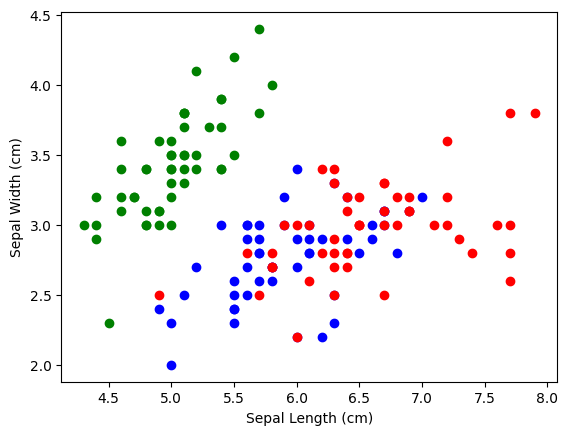

In [58]:
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color='green', label='Iris-Setosa')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='blue', label='Iris-Versicolor')
plt.scatter(df2['sepal length (cm)'], df2['sepal width (cm)'], color='red', label='Iris-Virginica')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

Text(0, 0.5, 'Petal Width (cm)')

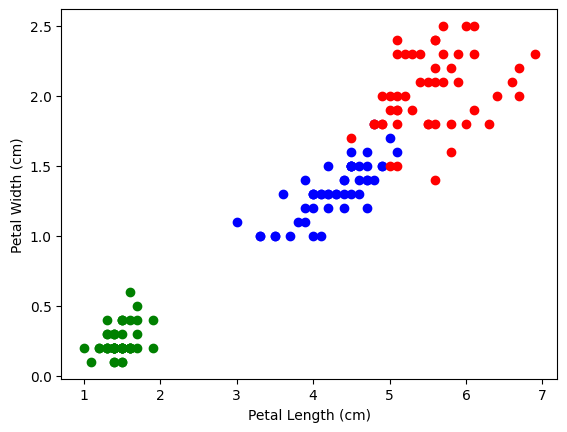

In [59]:
plt.scatter(df0["petal length (cm)"], df0["petal width (cm)"], color='green', label='Iris-Setosa')
plt.scatter(df1["petal length (cm)"], df1["petal width (cm)"], color='blue', label='Iris-Versicolor')
plt.scatter(df2["petal length (cm)"], df2["petal width (cm)"], color='red', label='Iris-Virginica')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

In [60]:
x= df.drop(['target', 'flower_name'], axis='columns')
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [61]:
y= df.target
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [63]:
iris_model = SVC()
iris_model.fit(x_train, y_train)


SVC()

In [64]:
iris_model.score(x_test, y_test)

1.0

In [65]:
from sklearn.datasets import load_digits
digits = load_digits()
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [66]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [67]:
digits.target[0]

np.int64(0)

In [155]:
X_train, X_test, Y_train, Y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)
digits_model = SVC(C=1, gamma=.001, kernel="rbf")  # C and gamma are hyperparameters for SVM
digits_model.fit(X_train, Y_train)

SVC(C=1, gamma=0.001)

In [156]:
digits_model.predict(X_test[0:5])


array([6, 9, 3, 7, 2])

In [157]:
digits_model.score(X_test, Y_test)

0.9888888888888889

C=1, gamma=.001, kernel="rbf" are giving the
best accuracy for predicting the digits